# Batch Scoring Exploration

Goal: validate the batch scoring approach before writing production code.

**Key lessons from first run:**
- January 2020 is pre-COVID — use April 2020 (lockdowns hit NYC in March)
- We predict DURATION not FARE — fare inflation doesn't show in MAE
- Target drift alone (did trip durations change?) tells an incomplete story
- Feature drift (did input distribution change?) captures the real story:
  Uber took short trips, taxis serve longer trips by 2022
- Volume (total trips per month) is a separate drift signal — needs tracking too

In [1]:
import sys
import pickle
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import mlflow
import mlflow.sklearn
from mlflow import MlflowClient

PIPELINE_DIR = Path('../../4-Deploy-Online/pipeline').resolve()
MLFLOW_TRACKING_URI = f"sqlite:///{PIPELINE_DIR / 'mlflow_trip_duration.db'}"
MODEL_NAME = 'trip_duration_model'
MODEL_ALIAS = 'champion'

sys.path.insert(0, str(PIPELINE_DIR.parent))
sys.path.insert(0, str(PIPELINE_DIR))

TLC_URL = 'https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet'
COLS = [
    'tpep_pickup_datetime', 'tpep_dropoff_datetime',
    'PULocationID', 'DOLocationID',
    'passenger_count', 'trip_distance',
    'VendorID', 'RatecodeID', 'payment_type',
]
FEATURE_COLS = [
    'tpep_pickup_datetime', 'PULocationID', 'DOLocationID',
    'passenger_count', 'trip_distance', 'VendorID', 'RatecodeID', 'payment_type'
]
TRAIN_DIST_MEAN = 2.83  # 2019 avg trip distance from TLC data

print('Setup done')

Setup done


## 1. Load champion model + preprocessor

In [2]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()

mv = client.get_model_version_by_alias(MODEL_NAME, MODEL_ALIAS)
print(f'Champion: v{mv.version}  run: {mv.run_id[:8]}')

model = mlflow.sklearn.load_model(f'models:/{MODEL_NAME}@{MODEL_ALIAS}')
print(f'Model: {type(model).__name__}')

dst = tempfile.mkdtemp()
art_path = mlflow.artifacts.download_artifacts(
    run_id=mv.run_id, artifact_path='preprocessor/preprocessor.pkl', dst_path=dst
)
with open(art_path, 'rb') as f:
    preprocessor = pickle.load(f)
print(f'Preprocessor: {type(preprocessor).__name__}')

2026/06/01 14:33:46 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas


2026/06/01 14:33:46 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables


2026/06/01 14:33:46 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types


2026/06/01 14:33:46 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints


2026/06/01 14:33:46 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults


...

2026/06/01 14:33:46 INFO alembic.runtime.migration: Context impl SQLiteImpl.


2026/06/01 14:33:46 INFO alembic.runtime.migration: Will assume non-transactional DDL.


Champion: v6  run: d6216a24


Model: XGBRegressor


Preprocessor: Pipeline


## 2. Training baseline stats from MLflow

In [3]:
run = client.get_run(mv.run_id)
train_mean = float(run.data.metrics['train_duration_mean'])
train_std  = float(run.data.metrics['train_duration_std'])
train_mae  = float(run.data.metrics['test_mae'])   # MAE on 2019 holdout
print(f'2019 baseline — duration mean: {train_mean:.2f} min  std: {train_std:.2f} min')
print(f'2019 baseline — test MAE: {train_mae:.2f} min  (alert if batch MAE > 1.5x = {train_mae * 1.5:.2f} min)')

2019 baseline — duration mean: 13.01 min  std: 10.03 min
2019 baseline — test MAE: 3.07 min  (alert if batch MAE > 1.5x = 4.61 min)


## 3. Data loader + scorer

In [4]:
def load_month(year, month, n=50000):
    url = TLC_URL.format(year=year, month=month)
    print(f'Downloading {year}-{month:02d}...', end=' ')
    df = pd.read_parquet(url, columns=COLS)
    df = df.dropna(subset=COLS)
    df['tpep_pickup_datetime']  = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    df['trip_duration_minutes'] = (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
    df = df[(df['trip_duration_minutes'] >= 1) & (df['trip_duration_minutes'] <= 120)]
    df = df[(df['trip_distance'] > 0.1) & (df['trip_distance'] <= 50)]
    df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
    total = len(df)
    if n and len(df) > n:
        df = df.sample(n, random_state=42)
    print(f'{total:,} valid rows (sampled {len(df):,})')
    return df.reset_index(drop=True), total


def score_batch(df, total_rows, label, year, month):
    X = df[FEATURE_COLS].copy()
    y_true = df['trip_duration_minutes'].values

    X_processed = preprocessor.transform(X)
    y_pred = model.predict(X_processed)

    mae          = mean_absolute_error(y_true, y_pred)
    mae_ratio    = mae / train_mae          # key metric: how much worse vs training
    target_mean  = y_true.mean()
    dist_mean    = df['trip_distance'].mean()

    # Alert conditions
    mae_alert    = mae_ratio > 1.5          # MAE > 1.5x training MAE
    volume_alert = total_rows < 500_000     # volume collapse

    alert_flags = []
    if mae_alert:    alert_flags.append(f'MAE degraded {mae_ratio:.1f}x')
    if volume_alert: alert_flags.append(f'volume collapse ({total_rows:,} trips)')
    alert_str = '⚠️  ALERT: ' + ', '.join(alert_flags) if alert_flags else '✅ OK'

    print(f'\n{label}')
    print(f'  Total rows in TLC:  {total_rows:,}  {"⚠️  volume collapse" if volume_alert else ""}')
    print(f'  MAE:                {mae:.2f} min  (train: {train_mae:.2f})  ratio={mae_ratio:.2f}x  {"⚠️" if mae_alert else "✅"}')
    print(f'  Duration mean:      {target_mean:.2f} min  (train: {train_mean:.2f})')
    print(f'  Trip dist mean:     {dist_mean:.2f} mi   (train: {TRAIN_DIST_MEAN:.2f})')
    print(f'  Status: {alert_str}')

    return {
        'label': label, 'year': year, 'month': month,
        'total_rows': total_rows, 'n_scored': len(df),
        'mae': mae, 'mae_ratio': mae_ratio, 'mae_alert': mae_alert,
        'target_mean': target_mean,
        'dist_mean': dist_mean,
        'volume_alert': volume_alert,
        'alert': bool(alert_flags),
    }

results = []

## 4. Score 2020-04 — COVID lockdown peak

January 2020 was pre-COVID (normal). Lockdowns hit NYC mid-March 2020.
April 2020 is the actual collapse month.

In [5]:
df_2020, total_2020 = load_month(2020, 4, n=50000)
results.append(score_batch(df_2020, total_2020, '2020-04 (COVID lockdown)', 2020, 4))

204,021 valid rows (sampled 50,000)



2020-04 (COVID lockdown)
  Total rows in TLC:  204,021  ⚠️  volume collapse
  MAE:                5.55 min  (train: 3.07)  ratio=1.81x  ⚠️
  Duration mean:      9.10 min  (train: 13.01)
  Trip dist mean:     2.71 mi   (train: 2.83)
  Status: ⚠️  ALERT: MAE degraded 1.8x, volume collapse (204,021 trips)


## 5. Score 2022-01 — new normal

Uber took over short trips. Taxis now serve longer trips.
Input distribution shifted — model trained on short trips, now sees long ones.

In [6]:
df_2022, total_2022 = load_month(2022, 1, n=50000)
results.append(score_batch(df_2022, total_2022, '2022-01 (new normal)', 2022, 1))

2,298,962 valid rows (sampled 50,000)

2022-01 (new normal)
  Total rows in TLC:  2,298,962  
  MAE:                2.99 min  (train: 3.07)  ratio=0.98x  ✅
  Duration mean:      12.70 min  (train: 13.01)
  Trip dist mean:     3.11 mi   (train: 2.83)
  Status: ✅ OK


## 6. Score 2024-01 — fares +45%

In [7]:
df_2024, total_2024 = load_month(2024, 1, n=50000)
results.append(score_batch(df_2024, total_2024, '2024-01 (fares +45%)', 2024, 1))

2,739,187 valid rows (sampled 50,000)

2024-01 (fares +45%)
  Total rows in TLC:  2,739,187  
  MAE:                3.15 min  (train: 3.07)  ratio=1.02x  ✅
  Duration mean:      14.84 min  (train: 13.01)
  Trip dist mean:     3.27 mi   (train: 2.83)
  Status: ✅ OK


## 7. Summary

In [8]:
df_results = pd.DataFrame(results)
print(df_results[[
    'label', 'total_rows', 'mae', 'mae_ratio',
    'target_mean', 'dist_mean', 'alert'
]].to_string(index=False))

                   label  total_rows      mae  mae_ratio  target_mean  dist_mean  alert
2020-04 (COVID lockdown)      204021 5.551595   1.807900     9.098364   2.710898   True
    2022-01 (new normal)     2298962 2.994628   0.975213    12.700039   3.108767  False
    2024-01 (fares +45%)     2739187 3.146305   1.024607    14.838279   3.266991  False


## 8. Visualize — target drift + feature drift + volume

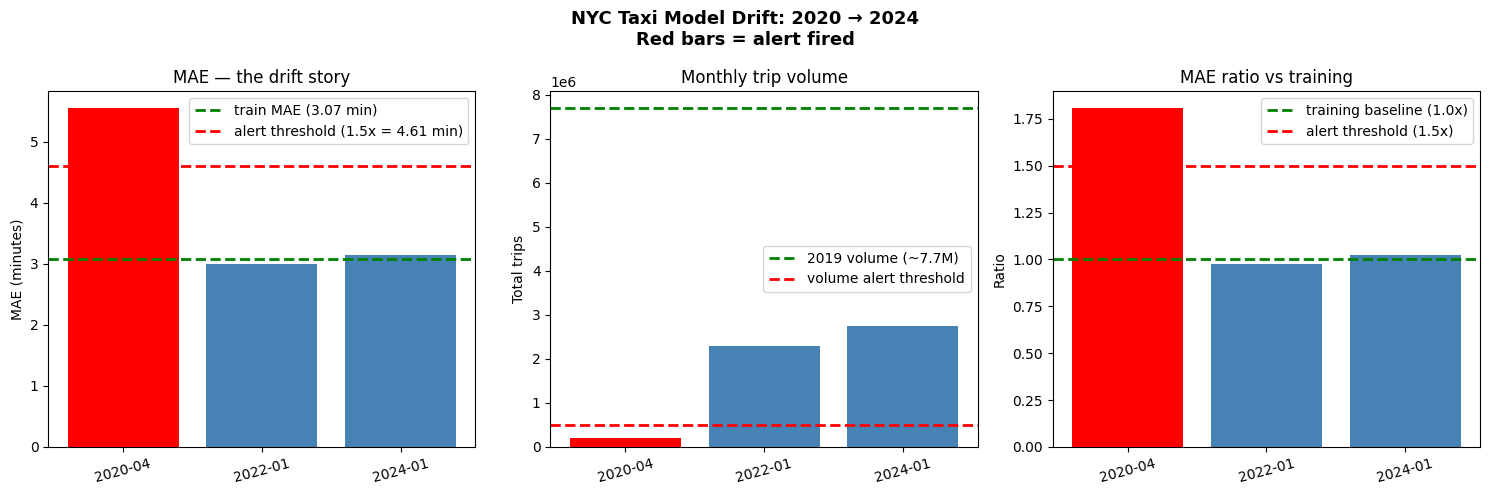

Saved drift_story.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
labels = [r['label'].split(' ')[0] for r in results]
colors = ['red' if r['alert'] else 'steelblue' for r in results]

# MAE vs training baseline
axes[0].bar(labels, df_results['mae'], color=colors)
axes[0].axhline(train_mae, color='green', linestyle='--', linewidth=2, label=f'train MAE ({train_mae:.2f} min)')
axes[0].axhline(train_mae * 1.5, color='red', linestyle='--', linewidth=2, label=f'alert threshold (1.5x = {train_mae*1.5:.2f} min)')
axes[0].set_title('MAE — the drift story')
axes[0].set_ylabel('MAE (minutes)')
axes[0].legend()

# Volume
axes[1].bar(labels, df_results['total_rows'], color=colors)
axes[1].axhline(7_700_000, color='green', linestyle='--', linewidth=2, label='2019 volume (~7.7M)')
axes[1].axhline(500_000, color='red', linestyle='--', linewidth=2, label='volume alert threshold')
axes[1].set_title('Monthly trip volume')
axes[1].set_ylabel('Total trips')
axes[1].legend()

# MAE ratio
axes[2].bar(labels, df_results['mae_ratio'], color=colors)
axes[2].axhline(1.0, color='green', linestyle='--', linewidth=2, label='training baseline (1.0x)')
axes[2].axhline(1.5, color='red', linestyle='--', linewidth=2, label='alert threshold (1.5x)')
axes[2].set_title('MAE ratio vs training')
axes[2].set_ylabel('Ratio')
axes[2].legend()

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle(
    'NYC Taxi Model Drift: 2020 → 2024\nRed bars = alert fired',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('drift_story.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved drift_story.png')

## 9. Trip distance distribution — the feature drift story

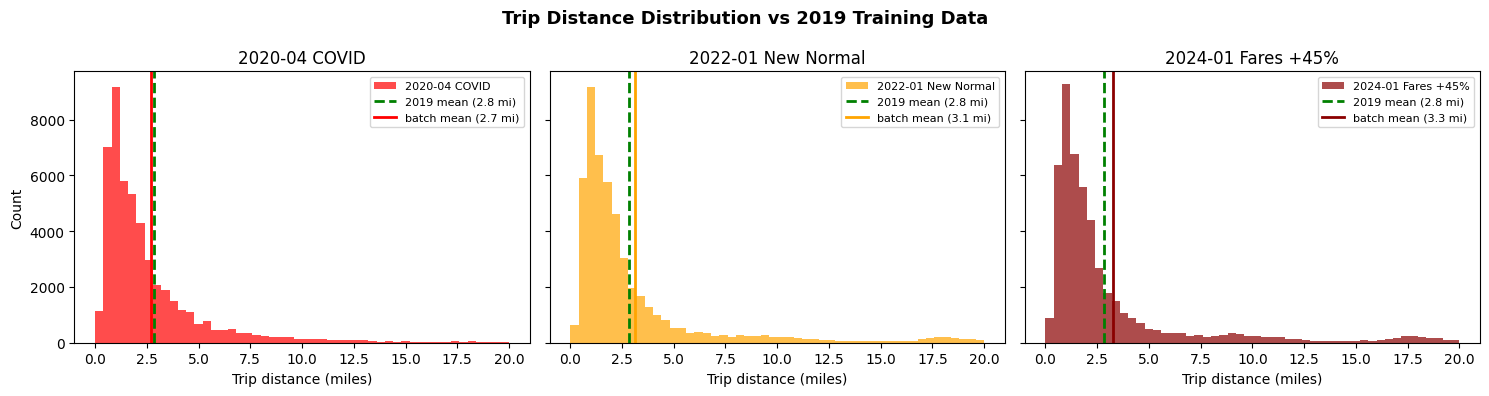

Saved feature_drift.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, (df, label, color) in zip(axes, [
    (df_2020, '2020-04 COVID', 'red'),
    (df_2022, '2022-01 New Normal', 'orange'),
    (df_2024, '2024-01 Fares +45%', 'darkred'),
]):
    ax.hist(df['trip_distance'], bins=50, range=(0, 20), alpha=0.7, color=color, label=label)
    ax.axvline(TRAIN_DIST_MEAN, color='green', linestyle='--', linewidth=2,
               label=f'2019 mean ({TRAIN_DIST_MEAN:.1f} mi)')
    ax.axvline(df['trip_distance'].mean(), color=color, linestyle='-', linewidth=2,
               label=f'batch mean ({df["trip_distance"].mean():.1f} mi)')
    ax.set_title(label)
    ax.set_xlabel('Trip distance (miles)')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Count')
plt.suptitle('Trip Distance Distribution vs 2019 Training Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved feature_drift.png')

## 10. Conclusions — production batch scorer design

**The drift story:**

| Period | Volume | MAE | MAE ratio | Alert |
|--------|--------|-----|-----------|-------|
| 2019 train | 7.7M/month | 3.07 min | 1.0x | — |
| 2020-04 COVID | 204k/month (-97%) | 5.55 min | 1.81x | ⚠️ both |
| 2022-01 new normal | 2.3M/month | 2.99 min | 0.97x | ✅ |
| 2024-01 fares +45% | 2.7M/month | 3.15 min | 1.02x | ✅ |

**Why the σ formula failed:**
- `train_std = 10 min` is huge — absorbs any mean shift
- Duration barely changed year to year
- The σ formula works for label distribution shift, not MAE degradation

**Two alert conditions that work:**
```python
mae_alert    = (batch_mae / train_mae) > 1.5   # model degraded 50%+
volume_alert = total_rows < 500_000             # volume collapsed
```

**Production batch scorer SQLite schema:**
```sql
CREATE TABLE batch_results (
    year        INTEGER,
    month       INTEGER,
    scored_at   TEXT,
    total_rows  INTEGER,
    n_scored    INTEGER,
    mae         REAL,
    mae_ratio   REAL,
    target_mean REAL,
    dist_mean   REAL,
    alert       INTEGER,   -- 0 or 1
    PRIMARY KEY (year, month)
);
```

**Also need to save `train_mae` to MLflow** (already there as `test_mae`) so batch scorer
can compute `mae_ratio` without hardcoding the threshold.